# EDA – CHRONO24 PRICE PREDICTION MODELS

# Load Data and Inspect

In [22]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv("/kaggle/input/datasets/philmorekoung11/luxury-watch-listings/Watches.csv")

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nFull duplicates: {df.duplicated().sum()}")
df.head()

/tmp/ipykernel_58/1086542098.py:6: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/philmorekoung11/luxury-watch-listings/Watches.csv")


Shape: (284491, 14)

Dtypes:
Unnamed: 0     int64
name          object
price         object
brand         object
model         object
ref           object
mvmt          object
casem         object
bracem        object
yop           object
cond          object
sex           object
size          object
condition     object
dtype: object

Missing values (%):
Unnamed: 0     0.00
name          25.51
price          0.14
brand          0.05
model         10.71
ref           15.17
mvmt          69.14
casem         57.74
bracem        61.48
yop            0.05
cond          26.71
sex           33.68
size           8.29
condition     74.84
dtype: float64

Full duplicates: 0


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [23]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Unnamed: 0 ---
[0 1 2 3 4 5 6 7 8 9]

--- name ---
["Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary'"
 'Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial'
 'Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd'
 'Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial'
 'Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01'
 'Audemars Piguet Royal Oak Offshore Diver\n2018 Unworn Royal Oak Offshore Diver (Limit 200pics)'
 'Audemars Piguet Royal Oak Offshore Diver Chronograph\n26703ST.OO.A051CA.01'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26470IO.OO.A006CA.01'
 'Audemars Piguet Royal Oak Dual Time\n26120ST.OO.1220ST.03'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26401.RO.OO.A002.CA.01']

--- price ---
['$43,500' '$71,500' '$79,191' '$108,000' '$27,500' '$41,000' '$37,800'
 '$32,182' '$36,473' '$35,000']

--- brand ---
['Audemars Piguet' 'Cartier' 'Tudor' 'Bre

# Cleaning

In [24]:
df = df.drop(columns=['Unnamed: 0'])

df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

df['condition'] = df['condition'].fillna(df['cond'])
df = df.drop(columns=['cond'])

df['yop_approx'] = df['yop'].str.contains('Approximation', na=False).astype(int)
df['yop'] = pd.to_numeric(df['yop'].str.extract(r'(\d{4})')[0], errors='coerce')

df['size_mm'] = pd.to_numeric(df['size'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df = df.drop(columns=['size'])

for col in ['mvmt', 'casem', 'bracem', 'sex', 'condition', 'model', 'brand']:
    df[col] = df[col].fillna('Unknown')

df = df.drop_duplicates(subset=['name', 'ref', 'price', 'brand'], keep='first')

print(f"Shape after cleaning: {df.shape}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nPrice stats:\n{df['price'].describe()}")
print(f"\nyop stats:\n{df['yop'].describe()}")
print(f"\nsize_mm stats:\n{df['size_mm'].describe()}")

Shape after cleaning: (247823, 13)

Missing values (%):
name          21.44
price          0.00
brand          0.00
model          0.00
ref           15.79
mvmt           0.00
casem          0.00
bracem         0.00
yop           34.34
sex            0.00
condition      0.00
yop_approx     0.00
size_mm        8.31
dtype: float64

Price stats:
count    2.478230e+05
mean     1.864181e+04
std      6.775256e+04
min      1.000000e+01
25%      2.850000e+03
50%      6.517000e+03
75%      1.568800e+04
max      9.000000e+06
Name: price, dtype: float64

yop stats:
count    162719.000000
mean       2009.034065
std          20.881424
min        1559.000000
25%        2003.000000
50%        2020.000000
75%        2023.000000
max        2024.000000
Name: yop, dtype: float64

size_mm stats:
count    2.272180e+05
mean     3.801021e+08
std      2.867050e+10
min      0.000000e+00
25%      3.600000e+01
50%      4.000000e+01
75%      4.200000e+01
max      2.724317e+12
Name: size_mm, dtype: float64


# EDA + Anomaly Treatment

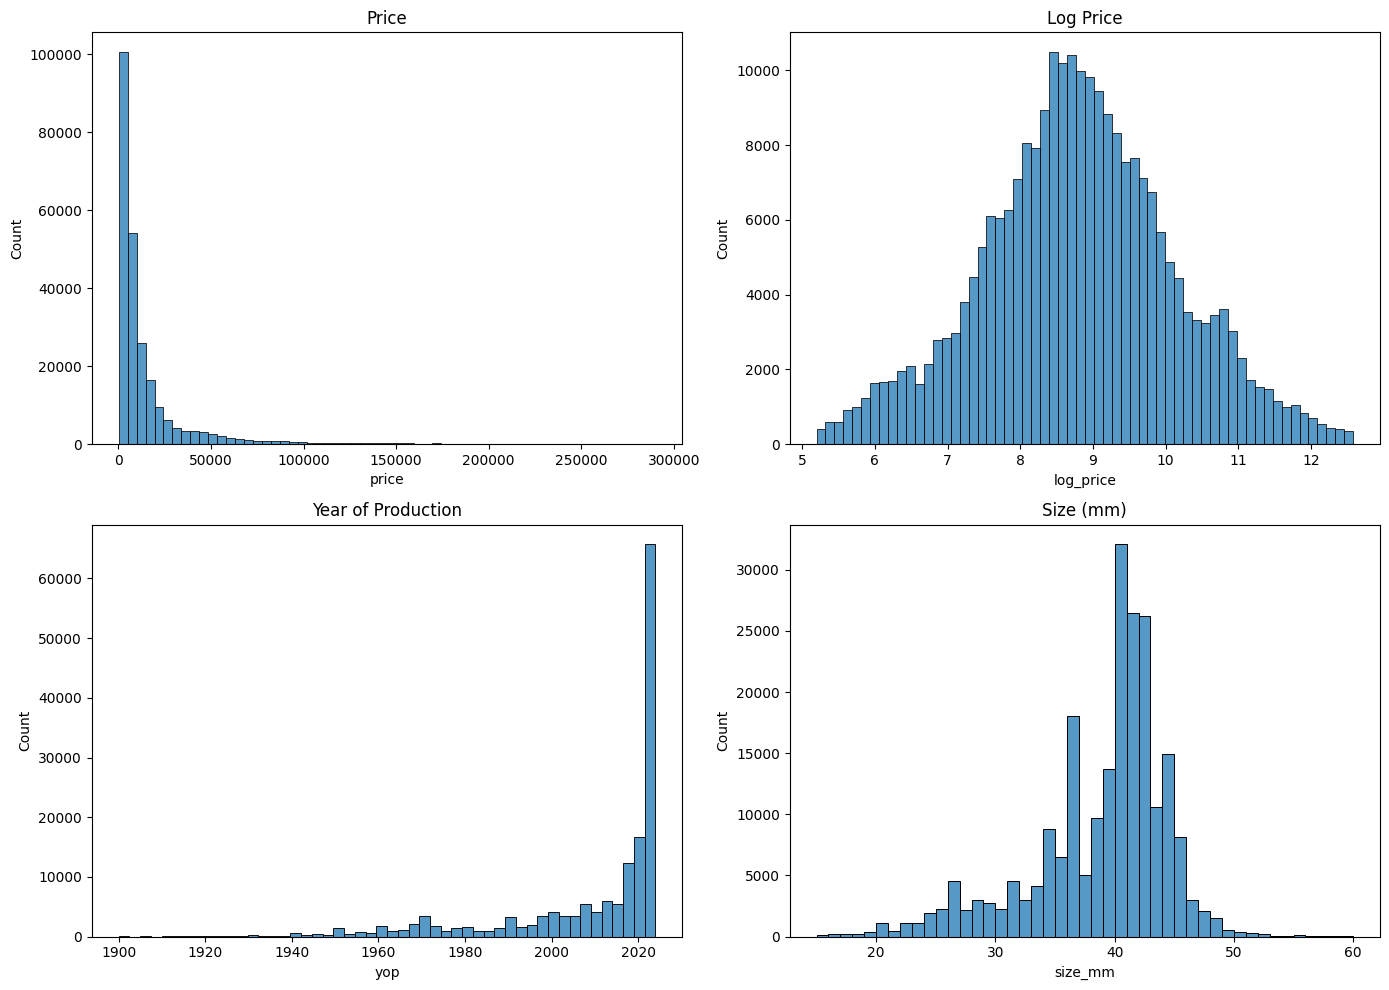

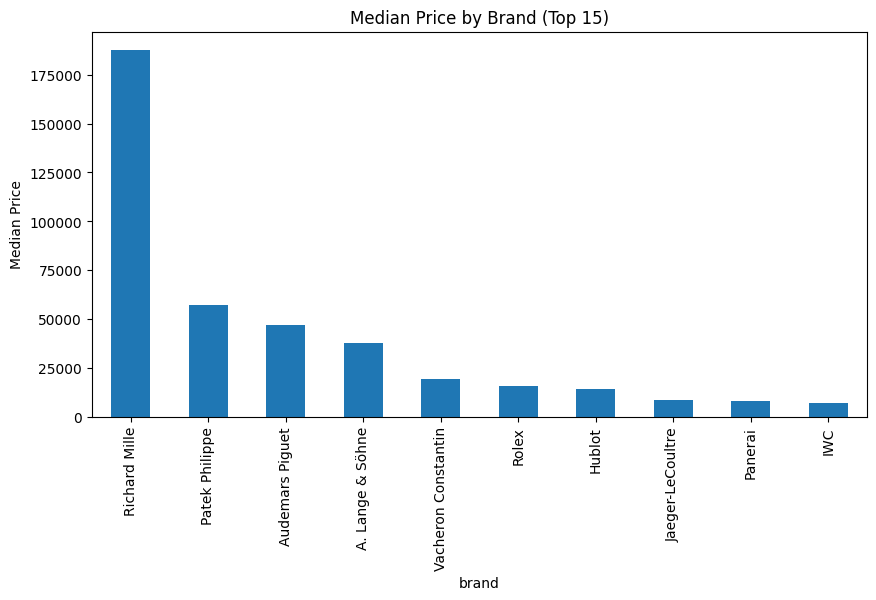

Shape: (245357, 14)
Price range: 180 - 290000

Brand counts (top 10):
brand
Rolex                  52932
Omega                  37505
Seiko                  17306
Breitling              16373
Cartier                15285
Longines               14713
TAG Heuer              12354
Hublot                 10901
Audemars Piguet        10389
Patek Philippe          9940
IWC                     9629
Tudor                   9325
Panerai                 6976
Zenith                  6104
Jaeger-LeCoultre        5434
Oris                    4506
Vacheron Constantin     3497
A. Lange & Söhne        1151
Sinn                     668
Richard Mille            357
NOMOS                      3
Edox                       2
Montblanc                  2
Tissot                     1
Rado                       1
Meistersinger              1
Hamilton                   1
Ebel                       1
Name: count, dtype: int64

Correlation with log_price:
log_price     1.000000
yop           0.210429
size_mm    

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df.loc[(df['size_mm'] < 15) | (df['size_mm'] > 60), 'size_mm'] = np.nan
df.loc[(df['yop'] < 1900) | (df['yop'] > 2026), 'yop'] = np.nan

low, high = df['price'].quantile([0.005, 0.995])
df = df[(df['price'] >= low) & (df['price'] <= high)]

df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['price'], bins=60, ax=axes[0, 0])
axes[0, 0].set_title('Price')
sns.histplot(df['log_price'], bins=60, ax=axes[0, 1])
axes[0, 1].set_title('Log Price')
sns.histplot(df['yop'].dropna(), bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Year of Production')
sns.histplot(df['size_mm'].dropna(), bins=45, ax=axes[1, 1])
axes[1, 1].set_title('Size (mm)')
plt.tight_layout()
plt.show()

top_brands = df.groupby('brand')['price'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
top_brands.plot(kind='bar')
plt.title('Median Price by Brand (Top 15)')
plt.ylabel('Median Price')
plt.show()

print(f"Shape: {df.shape}")
print(f"Price range: {df['price'].min():.0f} - {df['price'].max():.0f}")
print(f"\nBrand counts (top 10):\n{df['brand'].value_counts().head(50)}")
print(f"\nCorrelation with log_price:\n{df[['log_price', 'yop', 'size_mm', 'yop_approx']].corr()['log_price']}")

In [26]:
group_map = {
    'Rolex': 'C_rolex_style',
    'Tudor': 'C_rolex_style',
    'Omega': 'B_omega_pic',
    'Audemars Piguet': 'A_ap_style',
    'Patek Philippe': 'D_patek_style',
}

df['ref_group'] = df['brand'].map(group_map).fillna('E_F_generic_other')

print(df['ref_group'].value_counts())
print(f"\nTotal watches: {len(df)}")
print(f"\nBreakdown %:\n{(df['ref_group'].value_counts(normalize=True) * 100).round(2)}")

ref_group
E_F_generic_other    125266
C_rolex_style         62257
B_omega_pic           37505
A_ap_style            10389
D_patek_style          9940
Name: count, dtype: int64

Total watches: 245357

Breakdown %:
ref_group
E_F_generic_other    51.05
C_rolex_style        25.37
B_omega_pic          15.29
A_ap_style            4.23
D_patek_style         4.05
Name: proportion, dtype: float64


# Feature Engineering

In [27]:
CURRENT_YEAR = 2026

df['watch_age'] = CURRENT_YEAR - df['yop']
df['yop_missing'] = df['yop'].isna().astype(int)
df['size_missing'] = df['size_mm'].isna().astype(int)
df['yop'] = df['yop'].fillna(df['yop'].median())
df['size_mm'] = df['size_mm'].fillna(df.groupby('sex')['size_mm'].transform('median'))
df['watch_age'] = df['watch_age'].fillna(df['watch_age'].median())

df['same_material'] = (df['casem'] == df['bracem']).astype(int)
gold_pattern = 'gold|platinum'
df['precious_case'] = df['casem'].str.contains(gold_pattern, case=False, na=False).astype(int)
df['precious_brace'] = df['bracem'].str.contains(gold_pattern, case=False, na=False).astype(int)

df['name_len'] = df['name'].fillna('').str.len()
df['name_missing'] = df['name'].isna().astype(int)
df['has_limited'] = df['name'].fillna('').str.contains('limited|anniversary|edition', case=False).astype(int)

rare_brands = df['brand'].value_counts()[df['brand'].value_counts() < 10].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')

model_freq = df['model'].value_counts(normalize=True)
df['model_freq'] = df['model'].map(model_freq)

df_encoded = pd.get_dummies(df, columns=['brand', 'mvmt', 'casem', 'bracem', 'sex', 'condition'],
                            drop_first=True, dtype=int)

drop_cols = ['name', 'model', 'ref', 'price']
X = df_encoded.drop(columns=drop_cols + ['log_price'])
y = df_encoded['log_price']

print(f"X shape: {X.shape}")
print(f"\nFeature list:\n{X.columns.tolist()}")
print(f"\nAny NaN left: {X.isnull().sum().sum()}")
print(f"\nTop correlations with log_price:\n{df_encoded[X.select_dtypes(include=np.number).columns.tolist() + ['log_price']].corr()['log_price'].abs().sort_values(ascending=False).head(15)}")

X shape: (245357, 86)

Feature list:
['yop', 'yop_approx', 'size_mm', 'ref_group', 'watch_age', 'yop_missing', 'size_missing', 'same_material', 'precious_case', 'precious_brace', 'name_len', 'name_missing', 'has_limited', 'model_freq', 'brand_Audemars Piguet', 'brand_Breitling', 'brand_Cartier', 'brand_Hublot', 'brand_IWC', 'brand_Jaeger-LeCoultre', 'brand_Longines', 'brand_Omega', 'brand_Oris', 'brand_Other', 'brand_Panerai', 'brand_Patek Philippe', 'brand_Richard Mille', 'brand_Rolex', 'brand_Seiko', 'brand_Sinn', 'brand_TAG Heuer', 'brand_Tudor', 'brand_Vacheron Constantin', 'brand_Zenith', 'mvmt_Manual winding', 'mvmt_Quartz', 'mvmt_Unknown', 'casem_Bronze', 'casem_Carbon', 'casem_Ceramic', 'casem_Gold/Steel', 'casem_Palladium', 'casem_Plastic', 'casem_Platinum', 'casem_Red gold', 'casem_Rose gold', 'casem_Silver', 'casem_Steel', 'casem_Tantalum', 'casem_Titanium', 'casem_Tungsten', 'casem_Unknown', 'casem_White gold', 'casem_Yellow gold', 'bracem_Calf skin', 'bracem_Ceramic', 'bra